In [1]:
from google.colab import files
uploaded = files.upload()

Saving comments.csv to comments.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv('/content/comments.csv')

# Display first rows
print(df.head())

   id                 comment  User  id  Photo id created Timestamp  \
0   1         unde at dolorem         2         1  13-04-2023 08:04   
1   2         quae ea ducimus         3         1  13-04-2023 08:04   
2   3      alias a voluptatum         5         1  13-04-2023 08:04   
3   4    facere suscipit sunt        14         1  13-04-2023 08:04   
4   5  totam eligendi quaerat        17         1  13-04-2023 08:04   

  posted date emoji used  Hashtags used count  
0    April 14        yes                    1  
1    April 14         no                    2  
2    April 14         no                    4  
3    April 14        yes                    2  
4    April 14        yes                    1  


In [4]:
print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (7488, 8)

Columns:
Index(['id', 'comment', 'User  id', 'Photo id', 'created Timestamp',
       'posted date', 'emoji used', 'Hashtags used count'],
      dtype='object')

Missing Values:
id                     0
comment                0
User  id               0
Photo id               0
created Timestamp      0
posted date            0
emoji used             0
Hashtags used count    0
dtype: int64


In [5]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df.fillna('', inplace=True)

In [6]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert timestamp column
df['date'] = pd.to_datetime(df['created timestamp'])

# Extract features
df['day_name'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()
df['hour'] = df['date'].dt.hour

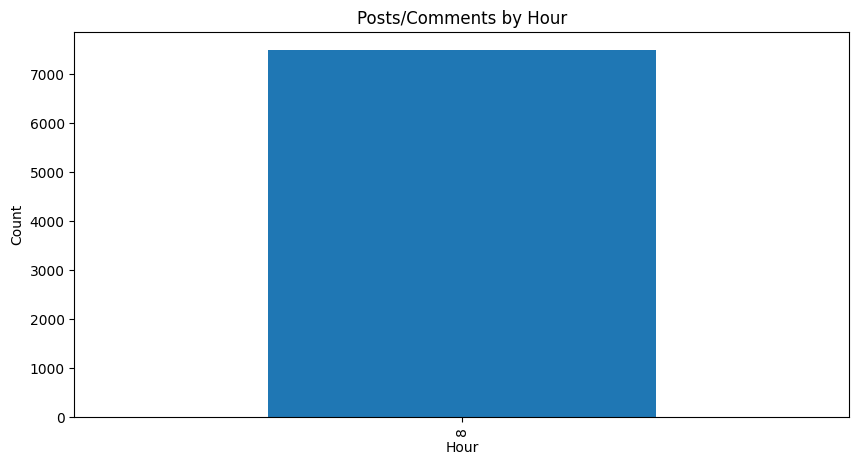

In [7]:
hour_posts = df.groupby('hour').size()

plt.figure(figsize=(10,5))
hour_posts.plot(kind='bar')
plt.title('Posts/Comments by Hour')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

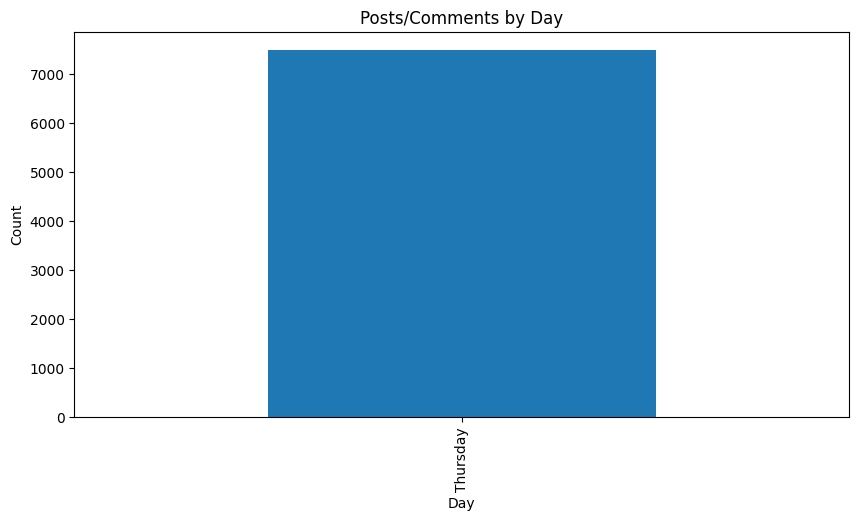

In [8]:
day_posts = df.groupby('day_name').size()

plt.figure(figsize=(10,5))
day_posts.plot(kind='bar')
plt.title('Posts/Comments by Day')
plt.xlabel('Day')
plt.ylabel('Count')
plt.show()

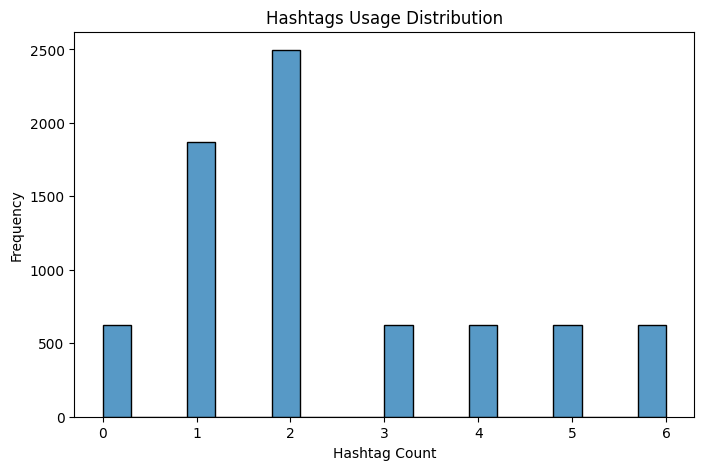

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['hashtags used count'], bins=20)

plt.title('Hashtags Usage Distribution')
plt.xlabel('Hashtag Count')
plt.ylabel('Frequency')
plt.show()

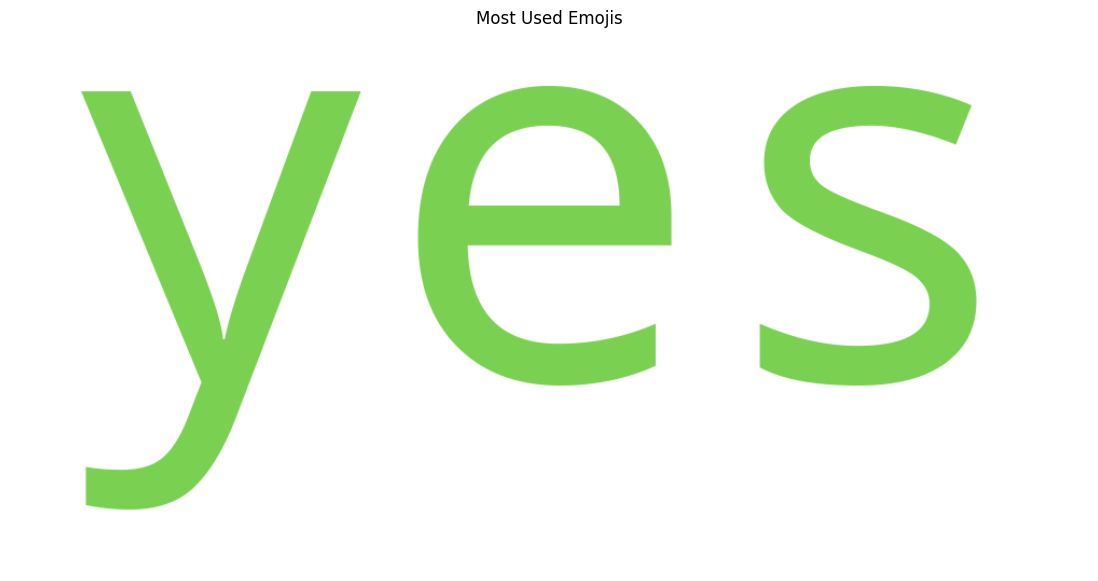

In [10]:
emoji_text = ' '.join(df['emoji used'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(emoji_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Used Emojis')
plt.show()

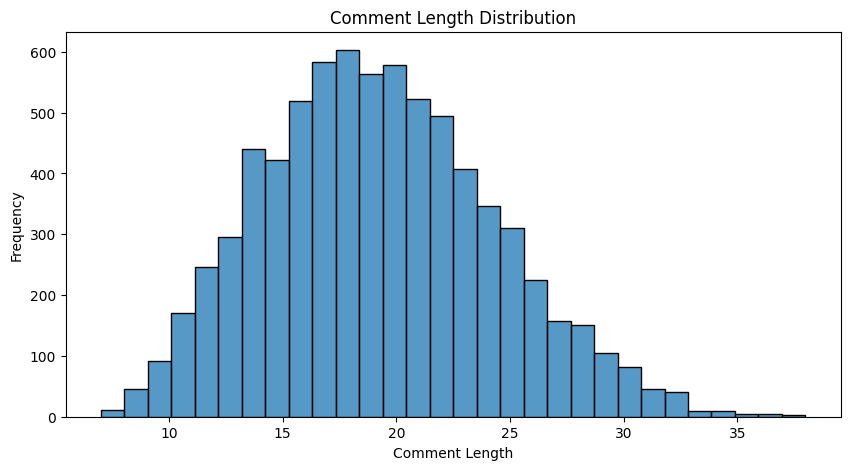

In [11]:
df['comment_length'] = df['comment'].astype(str).apply(len)

plt.figure(figsize=(10,5))
sns.histplot(df['comment_length'], bins=30)

plt.title('Comment Length Distribution')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()

In [12]:
top_users = df['user  id'].value_counts().head(10)

print("\nTop Active Users:")
print(top_users)


Top Active Users:
user  id
5     257
14    257
36    257
24    257
21    257
54    257
41    257
91    257
76    257
71    257
Name: count, dtype: int64


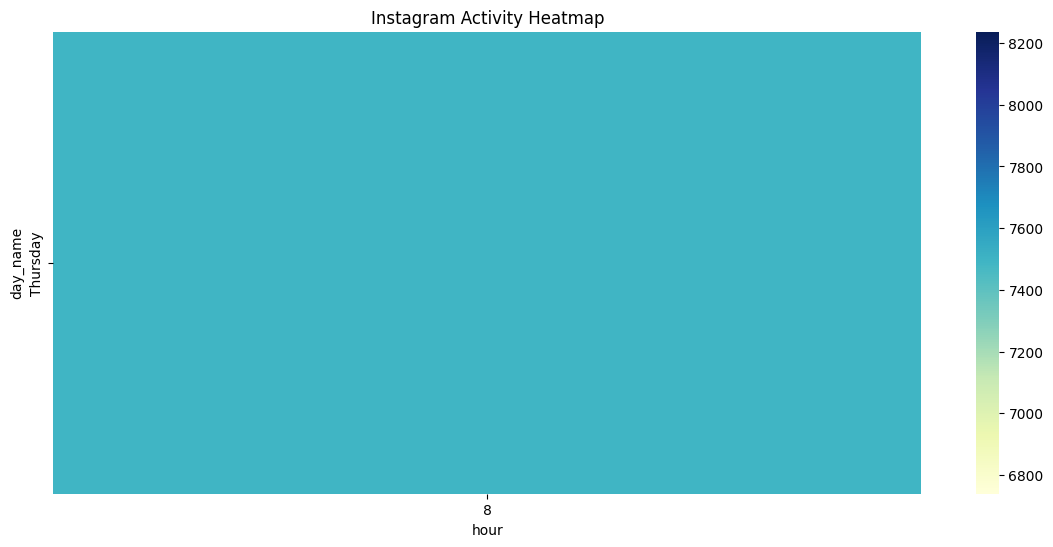

In [13]:
heatmap_data = df.pivot_table(
    index='day_name',
    columns='hour',
    values='id',
    aggfunc='count'
)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap='YlGnBu')

plt.title('Instagram Activity Heatmap')
plt.show()

In [14]:
print("\n========== INSIGHTS ==========")

best_hour = hour_posts.idxmax()
best_day = day_posts.idxmax()

print(f"Most Active Hour: {best_hour}:00")
print(f"Most Active Day: {best_day}")


========== INSIGHTS ==========
Most Active Hour: 8:00
Most Active Day: Thursday


In [15]:
strategies = [
    "Post during peak active hours",
    "Use optimized hashtag counts",
    "Include emojis for better interaction",
    "Encourage meaningful comments",
    "Maintain consistent posting schedule"
]

print("\n========== ALFIDO TECH STRATEGIES ==========")

for i, s in enumerate(strategies, 1):
    print(f"{i}. {s}")


========== ALFIDO TECH STRATEGIES ==========
1. Post during peak active hours
2. Use optimized hashtag counts
3. Include emojis for better interaction
4. Encourage meaningful comments
5. Maintain consistent posting schedule
